# Homework 7

## FINM 35700 - Spring 2026

Garrett White

In [3]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_path = list(uploaded.keys())[0]

extract_path = "/content/unzipped_files"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"\nExtracted to: {extract_path}\n")

for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    subindent = "  " * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Saving UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_7.zip to UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_7 (1).zip

Extracted to: /content/unzipped_files

unzipped_files/
  UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_7/
    credit_market_tools.py
    FINM 35700_CreditMarkets_Spring2026_Examples_QuantLib_ConvertibleBond.ipynb
    FINM 35700_CreditMarkets_Spring2026_Homework_7.ipynb


In [2]:
!pip install QuantLib-Python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 68.1 MB/s eta 0:00:00


In [4]:
import sys

extract_path = "/content/unzipped_files"

for root, dirs, files in os.walk(extract_path):
    if "credit_market_tools.py" in files:
        base_path = root
        break

print("Using path:", base_path)

sys.path.append(base_path)

from credit_market_tools import *

print("credit_market_tools imported successfully")

calc_date = ql.Date(23, 3, 2026)
ql.Settings.instance().evaluationDate = calc_date

as_of_date = pd.to_datetime('2026-03-23')

Using path: /content/unzipped_files/UChicago_FINM_35700_CreditMarkets_Spring2026_Homework_7
credit_market_tools imported successfully


-----------------------------------------------------------
# Problem 1: Options Pricing and Volatility Smiles in the Merton Structural Credit Model
## Follow Lecture 6, "Structural Credit Default Models"

We assume the following input values in the Merton Structural Credit Model
- Initial Assets of 1 (e.g. think about 1 $BN in assets at time 0)
- Face value of Liabilities K: 0.8 (e.g. initial leverage of 80%)
- Bond maturity T = 5 years
- Asset volatility at 10% (log-normal annualized vol)
- Flat risk-free interest rates of 4%
- Log-normal distribution of assets at time T, using Lecture 6 Formula (33):

$A_{T}=A_{0}\cdot\exp\left[\left(r-\frac{1}{2}\sigma_{A}^{2}\right)\cdot T+\sigma_{A}\cdot W_{T}\right]$


## a. Distributions of Assets and Equity fair values at time t = 1 year


Use the following discretization grid for Asset at time t: [a from 0.02 to 2 in steps of 0.02].

Compute the density (PDF) and cumulative density (CDF) of Assets at time t.

For each value of the assets, compute the fair value of Equity at time t.

Plot the results: Assets PDF, Assest CDF and Equity fair value at time t.

You can use lognorm from scipy.stats for the log-normal distribution PDF/CFD.

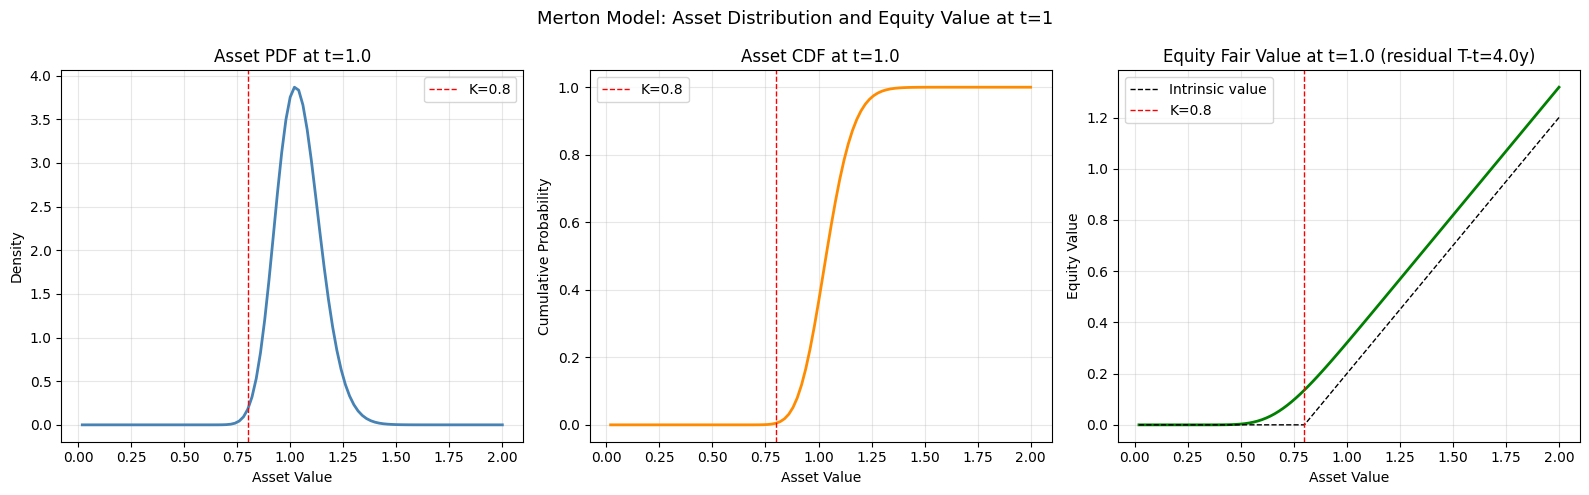

mu_ln    = 0.0350
sigma_ln = 0.1000
E[A_t]   = 1.0408  (should = A0*exp(r*t) = 1.0408)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

A0    = 1.0
K     = 0.8
T     = 5.0
sigma = 0.10
r     = 0.04
t     = 1.0

a_grid = np.arange(0.02, 2.01, 0.02)

mu_ln    = np.log(A0) + (r - 0.5 * sigma**2) * t
sigma_ln = sigma * np.sqrt(t)

dist  = lognorm(s=sigma_ln, scale=np.exp(mu_ln))
pdf   = dist.pdf(a_grid)
cdf   = dist.cdf(a_grid)

from scipy.stats import norm

tau = T - t

def bs_call(S, K, r, sigma, tau):
    if tau <= 0:
        return np.maximum(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

equity = np.array([bs_call(a, K, r, sigma, tau) for a in a_grid])

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(a_grid, pdf, color='steelblue', linewidth=2)
axes[0].axvline(K, color='red', linestyle='--', linewidth=1, label=f'K={K}')
axes[0].set_title(f'Asset PDF at t={t}')
axes[0].set_xlabel('Asset Value')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(a_grid, cdf, color='darkorange', linewidth=2)
axes[1].axvline(K, color='red', linestyle='--', linewidth=1, label=f'K={K}')
axes[1].set_title(f'Asset CDF at t={t}')
axes[1].set_xlabel('Asset Value')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(a_grid, equity, color='green', linewidth=2)
axes[2].plot(a_grid, np.maximum(a_grid - K, 0), 'k--', linewidth=1, label='Intrinsic value')
axes[2].axvline(K, color='red', linestyle='--', linewidth=1, label=f'K={K}')
axes[2].set_title(f'Equity Fair Value at t={t} (residual T-t={tau}y)')
axes[2].set_xlabel('Asset Value')
axes[2].set_ylabel('Equity Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Merton Model: Asset Distribution and Equity Value at t=1', fontsize=13)
plt.tight_layout()
plt.show()

print(f"mu_ln    = {mu_ln:.4f}")
print(f"sigma_ln = {sigma_ln:.4f}")
print(f"E[A_t]   = {dist.mean():.4f}  (should = A0*exp(r*t) = {A0*np.exp(r*t):.4f})")

## b. Compute the value of an Europen ATM (At-The-Money) Call option with maturity t = 1 year.

For ATM options, the strike k equals the equity value at time 0, i.e. $k = E_0$.

The Call Option value can be obtained by numerical integration of the call payoff function against the log-normal density of $A_t$, as derived in Lecture 6 formula (54).

You can use quad from scipy.integrate for numerical integration.

$EquityCall\left(E_{0},k,t\right)=e^{-r\cdot t}\cdot\mathbb{E}\left[\left(E_{t}-k\right)^{+}|\mathcal{F}_{0}\right]$

$=e^{-r\cdot t}\cdot\mathbb{E}\left[\left(Call\left(A_{t},K,T-t,\sigma_{A},r,\right)-k\right)^{+}|\mathcal{F}_{0}\right]$

$=\int_{-\infty}^{\infty}e^{-r\cdot t}\cdot\left(Call\left(x,K,T-t,\sigma_{A},r,\right)-k\right)^{+} \cdot \phi_{A_{t}} \, dx$

In [7]:
from scipy.integrate import quad

E0 = bs_call(A0, K, r, sigma, T)
k  = E0

print(f"E0 (ATM strike k) = {E0:.6f}")

def integrand(x):
    if x <= 0:
        return 0.0
    call_t = bs_call(x, K, r, sigma, tau)
    payoff  = max(call_t - k, 0.0)
    density = dist.pdf(x)
    return np.exp(-r * t) * payoff * density

call_value, error = quad(integrand, 0, np.inf, limit=200)

print(f"ATM Equity Call Value (numerical integration) = {call_value:.6f}")
print(f"Integration error estimate                    = {error:.2e}")

E0 (ATM strike k) = 0.347046
ATM Equity Call Value (numerical integration) = 0.045965
Integration error estimate                    = 6.65e-09


## c. Compute the Implied Volatility of the ATM European Call Option

Implement a function to compute the Implied Volatility in the Black-Scholes model (using European Call option price as input)

Compute the Implied Volatility of the ATM European Call Option.

Use a numerical root finder, e.g. root_scalar from scipy.optimize.

In [8]:
from scipy.optimize import root_scalar

def bs_call_price(S, K, r, sigma, t):
    if t <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * t) / (sigma * np.sqrt(t))
    d2 = d1 - sigma * np.sqrt(t)
    return S * norm.cdf(d1) - K * np.exp(-r * t) * norm.cdf(d2)

def implied_vol(price, S, K, r, t):
    objective = lambda sigma: bs_call_price(S, K, r, sigma, t) - price
    result = root_scalar(objective, bracket=[1e-6, 10.0], method='brentq')
    return result.root

S0_eq  = E0
iv_atm = implied_vol(call_value, S0_eq, k, r, t)

print(f"ATM Call Price          : {call_value:.6f}")
print(f"Equity spot (S)         : {E0:.6f}")
print(f"ATM Strike (K)          : {k:.6f}")
print(f"Implied Volatility (IV) : {iv_atm:.4%}")

ATM Call Price          : 0.045965
Equity spot (S)         : 0.347046
ATM Strike (K)          : 0.347046
Implied Volatility (IV) : 28.6726%


## d. Plot the option Implied Volatility Smile in the Merton model

Use a grid of strikes [k from 80% to 120% in steps of 5%], relative to the spot equity price E_0.

Compute the European Call options prices and the corresponding option Implied Volatilities on the above grid.
Plot the Implied Volatility smile (Implied Volatities by strikes).

  Strike 80% of E0 (0.2776): Price = 0.090227, IV = 30.5341%
  Strike 85% of E0 (0.2950): Price = 0.077579, IV = 30.0238%
  Strike 90% of E0 (0.3123): Price = 0.065834, IV = 29.4495%
  Strike 95% of E0 (0.3297): Price = 0.055390, IV = 29.0960%
  Strike 100% of E0 (0.3470): Price = 0.045965, IV = 28.6726%
  Strike 105% of E0 (0.3644): Price = 0.037674, IV = 28.2732%
  Strike 110% of E0 (0.3818): Price = 0.030494, IV = 27.8956%
  Strike 115% of E0 (0.3991): Price = 0.024374, IV = 27.5382%
  Strike 120% of E0 (0.4165): Price = 0.019238, IV = 27.1993%


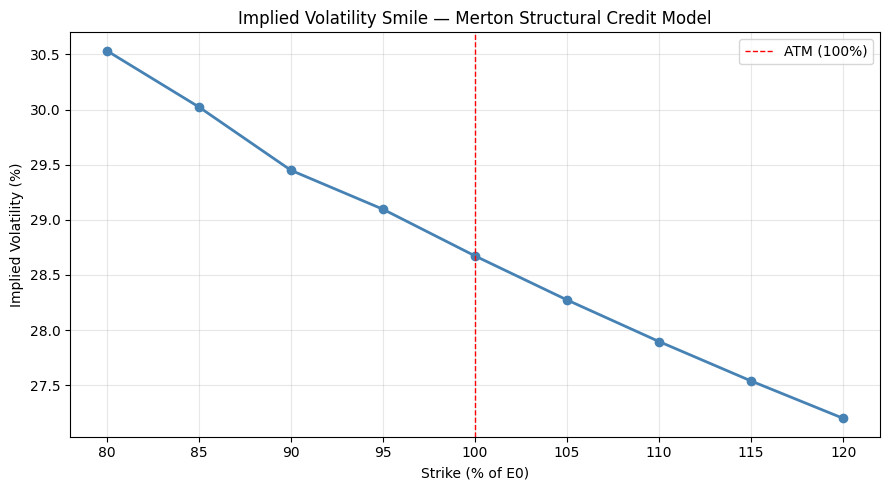

In [9]:
strike_pcts = np.arange(0.80, 1.21, 0.05)
strikes     = strike_pcts * E0

iv_smile    = []
call_prices = []

for strike in strikes:
    def integrand_k(x):
        if x <= 0:
            return 0.0
        call_t = bs_call(x, K, r, sigma, tau)
        payoff  = max(call_t - strike, 0.0)
        density = dist.pdf(x)
        return np.exp(-r * t) * payoff * density

    price, _ = quad(integrand_k, 0, np.inf, limit=200)
    call_prices.append(price)

    if price > 1e-8:
        iv = implied_vol(price, E0, strike, r, t)
    else:
        iv = np.nan
    iv_smile.append(iv)

iv_smile    = np.array(iv_smile)
call_prices = np.array(call_prices)

for pct, strike, price, iv in zip(strike_pcts, strikes, call_prices, iv_smile):
    print(f"  Strike {pct:.0%} of E0 ({strike:.4f}): Price = {price:.6f}, IV = {iv:.4%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strike_pcts * 100, iv_smile * 100, color='steelblue', linewidth=2, marker='o')
ax.axvline(100, color='red', linestyle='--', linewidth=1, label='ATM (100%)')
ax.set_title('Implied Volatility Smile — Merton Structural Credit Model')
ax.set_xlabel('Strike (% of E0)')
ax.set_ylabel('Implied Volatility (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

-----------------------------------------------------------
# Problem 2: Pricing Convertible Bonds in the Merton Structural Credit Model
## Follow Lecture 7, "Convertible Bonds"

A convertible bond is a type of corporate bond that can be converted into a predetermined number of the issuing company’s common stock ("conversion ratio") at the bondholder’s discretion, typically at specific dates. The conversion to equity is optional, so bondholders can choose to hold the bond to maturity for interest and principal repayment instead.

Benefits for convertible bond investors:
- Income from interest payments.
- Potential capital gains if the stock price increases and conversion is profitable.
- Lower risk than owning stock directly, as bondholders are prioritized over shareholders in case of bankruptcy.

Benefits for convertible bond issuers:
- Lower interest rates than regular bonds due to the conversion feature’s appeal.
- Potential to reduce debt if bonds are converted to equity.


The Merton structural credit model (1974) provides a framework for pricing convertible bonds by treating them as hybrid instruments with both debt and equity characteristics.

### Recap of model assumptions

- Constant interest rates r

- Constant asset volatility $\sigma_{A}$

- Asset value process $A_{t}$ follows a geometric Brownian motion with drift r under risk neutral measure $\mathbb{P}$

- Liabilities consist of one zero-coupon convertible bond with face value K and maturity T

- Conversion details: at time T, the convertible bond can be converted to equity at a conversion ratio of $C \in (0,1)$ relative to the assets $A_{T}$ (i.e. for a convertible bond payout of $C \cdot A_{T}$ at time T, in case of conversion)

- Credit default triggered if value of assets $A_{T}$ is below liabilities K at maturity T.


## a. Compute the fair value of the Convertible Bond

Derive the formula for the Convertible Bond payout at time T and compute the fair value $CB_0$ of the convertible bond at time 0.

You can use the formulas for the fair value of the "vanilla" corporate bond $B_0$ (without callability) at time 0, derived in Lecture 7.

For which values of $A_T$ is it economical for the convertible bond holder to exercise the call option?

In [12]:
C     = 0.5
conversion_threshold = K / C

print(f"Conversion threshold K/C = {K}/{C} = {conversion_threshold:.4f}")
print(f"Conversion is optimal when A_T > K/C = {conversion_threshold:.4f}")

def merton_components(A0, strike, r, sigma, T):
    d1 = (np.log(A0 / strike) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

d1_K,   d2_K   = merton_components(A0, K,                    r, sigma, T)
d1_KoC, d2_KoC = merton_components(A0, conversion_threshold, r, sigma, T)

PV = np.exp(-r * T)
F  = A0 * np.exp(r * T)

E_AT_below_K   = F * norm.cdf(-d1_K)
E_AT_above_KoC = F * norm.cdf(d1_KoC)
P_below_K      = norm.cdf(-d2_K)
P_above_KoC    = norm.cdf(d2_KoC)
P_between      = 1 - P_below_K - P_above_KoC

default_leg_val    = PV * E_AT_below_K
par_leg_val        = PV * K * P_between
conversion_leg_val = PV * C * E_AT_above_KoC

CB0 = default_leg_val + par_leg_val + conversion_leg_val

B0  = PV * (E_AT_below_K + K * norm.cdf(d2_K))
E0  = bs_call(A0, K, r, sigma, T)

print(f"\n── Fair Value Decomposition ──────────────────")
print(f"  Default leg PV     : {default_leg_val:.6f}")
print(f"  Par leg PV         : {par_leg_val:.6f}")
print(f"  Conversion leg PV  : {conversion_leg_val:.6f}")
print(f"\n  CB0 (Convertible)  : {CB0:.6f}")
print(f"  B0  (Vanilla bond) : {B0:.6f}")
print(f"  CB0 - B0 (option)  : {CB0 - B0:.6f}")
print(f"  E0  (Equity)       : {E0:.6f}")
print(f"  CB0 + E0           : {CB0 + E0:.6f}  (should = A0={A0})")

Conversion threshold K/C = 0.8/0.5 = 1.6000
Conversion is optimal when A_T > K/C = 1.6000

── Fair Value Decomposition ──────────────────
  Default leg PV     : 0.022527
  Par leg PV         : 0.569163
  Conversion leg PV  : 0.068304

  CB0 (Convertible)  : 0.659994
  B0  (Vanilla bond) : 0.652954
  CB0 - B0 (option)  : 0.007040
  E0  (Equity)       : 0.347046
  CB0 + E0           : 1.007040  (should = A0=1.0)


In [13]:
print(f"\n── Balance Sheet Check ───────────────────────")
print(f"  A0                          : {A0:.6f}")
print(f"  CB0                         : {CB0:.6f}")

diluted_equity = PV * ((1 - C) * E_AT_above_KoC + (F - E_AT_below_K - E_AT_above_KoC) - K * P_between)
vanilla_equity = PV * (F - E_AT_below_K - K * norm.cdf(d2_K))

print(f"  Diluted Equity (with CB)    : {diluted_equity:.6f}")
print(f"  Vanilla Equity E0           : {E0:.6f}")
print(f"  CB0 + Diluted Equity        : {CB0 + diluted_equity:.6f}  (should = A0={A0})")
print(f"  CB0 + Vanilla Equity        : {CB0 + vanilla_equity:.6f}")
print(f"\n  Conversion option value     : {CB0 - B0:.6f}")
print(f"  (CB0 - B0) as % of B0      : {(CB0 - B0)/B0:.4%}")


── Balance Sheet Check ───────────────────────
  A0                          : 1.000000
  CB0                         : 0.659994
  Diluted Equity (with CB)    : 0.340006
  Vanilla Equity E0           : 0.347046
  CB0 + Diluted Equity        : 1.000000  (should = A0=1.0)
  CB0 + Vanilla Equity        : 1.007040

  Conversion option value     : 0.007040
  (CB0 - B0) as % of B0      : 1.0781%


## b. Compute the fair value of (Convertible) Equity

Derive the formula for the (Convertible) Equity Investor payout at time T: take into acount that the equity investor gets dilluted if the convertible bond is exercised.

Compute the fair value $CE_0$ of equity at time 0.

You can use the formulas for the fair value of "vanilla" equity $E_0$ (without callability) at time 0, derived in Lecture 7.

In [14]:
CE0 = PV * ((1 - C) * E_AT_above_KoC + (F - E_AT_below_K - E_AT_above_KoC) - K * P_between)

print(f"── Convertible Equity Fair Value ─────────────")
print(f"  Vanilla Equity  E0  : {E0:.6f}")
print(f"  Convertible Equity CE0 : {CE0:.6f}")
print(f"  Dilution cost E0-CE0   : {E0 - CE0:.6f}")
print(f"\n── Balance Sheet Verify ──────────────────────")
print(f"  CB0 + CE0           : {CB0 + CE0:.6f}  (should = A0={A0})")

── Convertible Equity Fair Value ─────────────
  Vanilla Equity  E0  : 0.347046
  Convertible Equity CE0 : 0.340006
  Dilution cost E0-CE0   : 0.007040

── Balance Sheet Verify ──────────────────────
  CB0 + CE0           : 1.000000  (should = A0=1.0)


## c. Numerical results

Under the following assumptions (matching Homework 7 Problem 1):
- Assets of $125 MM,
- Asset volatility at 20% (log-normal annualized vol)
- Flat risk-free interest rates of 4%
- Convertible Bond face value of $100 MM
- Convertible Bond maturity at T = 5 years
- Convertible Bond "conversion ratio" of 40% of Assets (at time T)


Compute the:
1. fair value of the (risky) convertible bond $CB_0$ at time 0,
2. fair value of the (convertible) equity $CE_0$ at time 0,
3. fair value of the conversion call option at time 0,
4. Convertible Bond Yield
5. Convertible Bond Credit Spread

and compare with the "vanilla" versions, when the bond is not callable (Homework 7 Problem 1).

In [16]:
A0_c  = 125e6
K_c   = 100e6
T_c   = 5.0
sigma_c = 0.20
r_c   = 0.04
C_c   = 0.40

conversion_threshold_c = K_c / C_c

d1_K_c,   d2_K_c   = merton_components(A0_c, K_c,                    r_c, sigma_c, T_c)
d1_KoC_c, d2_KoC_c = merton_components(A0_c, conversion_threshold_c, r_c, sigma_c, T_c)

PV_c = np.exp(-r_c * T_c)
F_c  = A0_c * np.exp(r_c * T_c)

E_AT_below_K_c   = F_c * norm.cdf(-d1_K_c)
E_AT_above_KoC_c = F_c * norm.cdf(d1_KoC_c)
P_below_K_c      = norm.cdf(-d2_K_c)
P_above_KoC_c    = norm.cdf(d2_KoC_c)
P_between_c      = 1 - P_below_K_c - P_above_KoC_c

default_leg_c    = PV_c * E_AT_below_K_c
par_leg_c        = PV_c * K_c * P_between_c
conversion_leg_c = PV_c * C_c * E_AT_above_KoC_c

CB0_c  = default_leg_c + par_leg_c + conversion_leg_c
CE0_c  = PV_c * ((1 - C_c) * E_AT_above_KoC_c + (F_c - E_AT_below_K_c - E_AT_above_KoC_c) - K_c * P_between_c)
B0_c   = PV_c * (E_AT_below_K_c + K_c * norm.cdf(d2_K_c))
E0_c   = bs_call(A0_c, K_c, r_c, sigma_c, T_c)

conv_option_c  = CB0_c - B0_c
cb_yield       = -np.log(CB0_c / K_c) / T_c
b_yield        = -np.log(B0_c  / K_c) / T_c
cb_spread      = (cb_yield - r_c) * 1e4
b_spread       = (b_yield  - r_c) * 1e4

print(f"── Parameters ────────────────────────────────")
print(f"  A0 = ${A0_c/1e6:.0f}MM, K = ${K_c/1e6:.0f}MM, T = {T_c}Y, σ = {sigma_c:.0%}, r = {r_c:.0%}, C = {C_c:.0%}")
print(f"  Conversion threshold K/C = ${conversion_threshold_c/1e6:.0f}MM")

print(f"\n── Fair Values ───────────────────────────────")
print(f"  {'Metric':<30} {'Convertible':>14} {'Vanilla':>14}")
print(f"  {'-'*60}")
print(f"  {'Bond Value':<30} ${CB0_c/1e6:>12.4f}MM  ${B0_c/1e6:>12.4f}MM")
print(f"  {'Equity Value':<30} ${CE0_c/1e6:>12.4f}MM  ${E0_c/1e6:>12.4f}MM")
print(f"  {'Conversion Option':<30} ${conv_option_c/1e6:>12.4f}MM  {'N/A':>14}")
print(f"  {'Bond Yield':<30} {cb_yield:>13.4%}  {b_yield:>13.4%}")
print(f"  {'Credit Spread':<30} {cb_spread:>12.2f}bps  {b_spread:>12.2f}bps")

print(f"\n── Balance Sheet Verify ──────────────────────")
print(f"  CB0 + CE0 = ${(CB0_c + CE0_c)/1e6:.4f}MM  (should = A0 = ${A0_c/1e6:.0f}MM)")

── Parameters ────────────────────────────────
  A0 = $125MM, K = $100MM, T = 5.0Y, σ = 20%, r = 4%, C = 40%
  Conversion threshold K/C = $250MM

── Fair Values ───────────────────────────────
  Metric                            Convertible        Vanilla
  ------------------------------------------------------------
  Bond Value                     $     79.6869MM  $     77.7657MM
  Equity Value                   $     45.3131MM  $     47.2343MM
  Conversion Option              $      1.9212MM             N/A
  Bond Yield                           4.5413%        5.0294%
  Credit Spread                         54.13bps        102.94bps

── Balance Sheet Verify ──────────────────────
  CB0 + CE0 = $125.0000MM  (should = A0 = $125MM)


## d. Plot various Convertible Equity + Bond metrics

Plot the Fair Value of
- Vanilla Equity,
- Convertible Equity,


Plot the Fair Value of
- Vanilla Bond
- Convertible Bond


Plot the following yields:
- Vanilla Bond Yields to maturity
- Convertible Bond Yields to maturity

on a grid of initial Asset values, from $50 MM to $200 MM in steps of $5 MM.


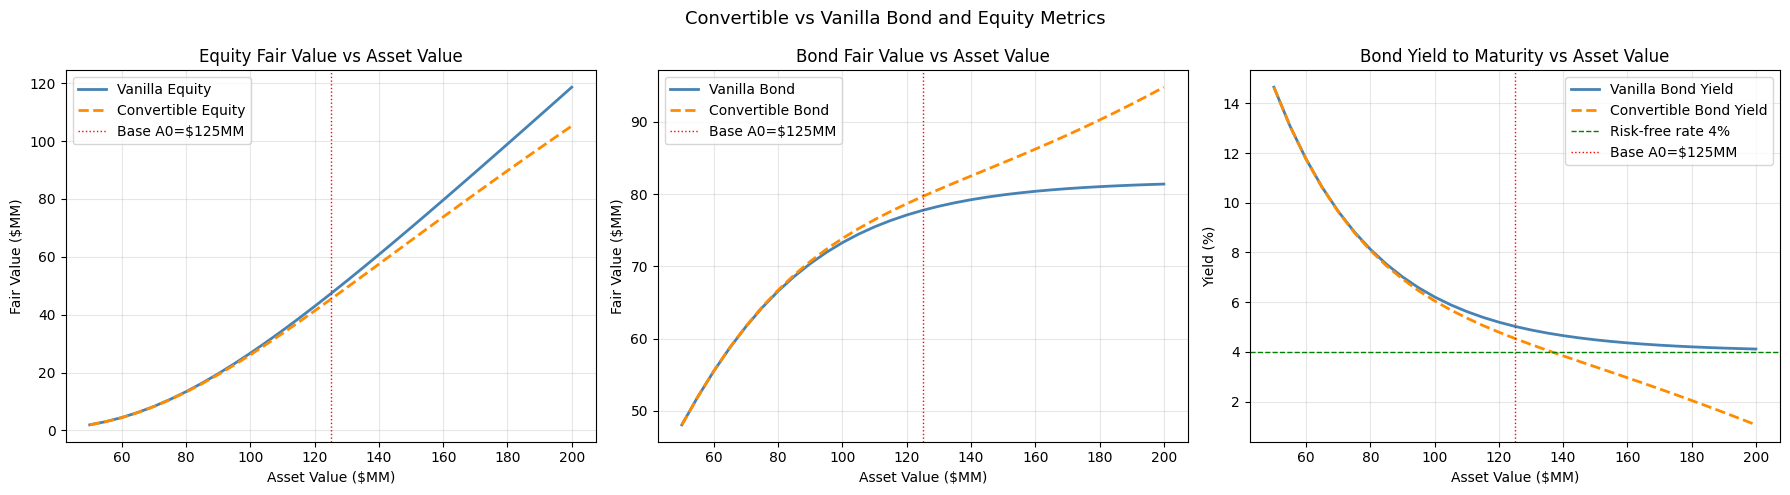

In [17]:
A0_grid = np.arange(50e6, 205e6, 5e6)

vanilla_equity_grid    = []
convertible_equity_grid = []
vanilla_bond_grid      = []
convertible_bond_grid  = []
vanilla_yield_grid     = []
convertible_yield_grid = []

for A in A0_grid:
    d1_K_g,   d2_K_g   = merton_components(A, K_c,                    r_c, sigma_c, T_c)
    d1_KoC_g, d2_KoC_g = merton_components(A, conversion_threshold_c, r_c, sigma_c, T_c)

    F_g = A * np.exp(r_c * T_c)

    E_AT_below_K_g   = F_g * norm.cdf(-d1_K_g)
    E_AT_above_KoC_g = F_g * norm.cdf(d1_KoC_g)
    P_below_K_g      = norm.cdf(-d2_K_g)
    P_above_KoC_g    = norm.cdf(d2_KoC_g)
    P_between_g      = 1 - P_below_K_g - P_above_KoC_g

    B_g  = PV_c * (E_AT_below_K_g + K_c * norm.cdf(d2_K_g))
    E_g  = bs_call(A, K_c, r_c, sigma_c, T_c)

    CB_g = PV_c * (E_AT_below_K_g + K_c * P_between_g + C_c * E_AT_above_KoC_g)
    CE_g = PV_c * ((1 - C_c) * E_AT_above_KoC_g + (F_g - E_AT_below_K_g - E_AT_above_KoC_g) - K_c * P_between_g)

    y_b  = -np.log(max(B_g,  1e-10) / K_c) / T_c
    y_cb = -np.log(max(CB_g, 1e-10) / K_c) / T_c

    vanilla_equity_grid.append(E_g)
    convertible_equity_grid.append(CE_g)
    vanilla_bond_grid.append(B_g)
    convertible_bond_grid.append(CB_g)
    vanilla_yield_grid.append(y_b)
    convertible_yield_grid.append(y_cb)

A0_mm = A0_grid / 1e6

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(A0_mm, np.array(vanilla_equity_grid)    / 1e6, color='steelblue',  linewidth=2, label='Vanilla Equity')
axes[0].plot(A0_mm, np.array(convertible_equity_grid) / 1e6, color='darkorange', linewidth=2, label='Convertible Equity', linestyle='--')
axes[0].axvline(A0_c / 1e6, color='red', linestyle=':', linewidth=1, label=f'Base A0=${A0_c/1e6:.0f}MM')
axes[0].set_title('Equity Fair Value vs Asset Value')
axes[0].set_xlabel('Asset Value ($MM)')
axes[0].set_ylabel('Fair Value ($MM)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(A0_mm, np.array(vanilla_bond_grid)      / 1e6, color='steelblue',  linewidth=2, label='Vanilla Bond')
axes[1].plot(A0_mm, np.array(convertible_bond_grid)  / 1e6, color='darkorange', linewidth=2, label='Convertible Bond', linestyle='--')
axes[1].axvline(A0_c / 1e6, color='red', linestyle=':', linewidth=1, label=f'Base A0=${A0_c/1e6:.0f}MM')
axes[1].set_title('Bond Fair Value vs Asset Value')
axes[1].set_xlabel('Asset Value ($MM)')
axes[1].set_ylabel('Fair Value ($MM)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(A0_mm, np.array(vanilla_yield_grid)     * 100, color='steelblue',  linewidth=2, label='Vanilla Bond Yield')
axes[2].plot(A0_mm, np.array(convertible_yield_grid) * 100, color='darkorange', linewidth=2, label='Convertible Bond Yield', linestyle='--')
axes[2].axhline(r_c * 100, color='green', linestyle='--', linewidth=1, label=f'Risk-free rate {r_c:.0%}')
axes[2].axvline(A0_c / 1e6, color='red', linestyle=':', linewidth=1, label=f'Base A0=${A0_c/1e6:.0f}MM')
axes[2].set_title('Bond Yield to Maturity vs Asset Value')
axes[2].set_xlabel('Asset Value ($MM)')
axes[2].set_ylabel('Yield (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Convertible vs Vanilla Bond and Equity Metrics', fontsize=13)
plt.tight_layout()
plt.show()

-----------------------------------------------------------
# Problem 3: Correlated defaults: homogeneous issuers case
## Follow Lecture 7, "Correlated Defaults"
We are analyzing a pool consisting of n = 100 equally weighted credit issuers with $100 total face notional. Our investment time horizon is T = 5 years.

The pool is homogenous, and each issuer has:
1. a flat hazard rate h = 12%,
2. a constant recovery rate given default of R of 40% and
3. a correlation $\rho$ to the systematic (market) factor.

## a. Expected pool loss to time T

Compute the expected loss in the pool until time T.

In [18]:
n   = 100
T   = 5.0
h   = 0.12
R   = 0.40
rho = 0.30
notional = 100.0

PD   = 1 - np.exp(-h * T)
LGD  = 1 - R
EL   = notional * PD * LGD

print(f"── Expected Pool Loss ────────────────────────")
print(f"  PD (single issuer, T={T}Y) : {PD:.4%}")
print(f"  LGD                        : {LGD:.4%}")
print(f"  Expected Loss              : ${EL:.4f}  ({EL/notional:.4%} of notional)")

── Expected Pool Loss ────────────────────────
  PD (single issuer, T=5.0Y) : 45.1188%
  LGD                        : 60.0000%
  Expected Loss              : $27.0713  (27.0713% of notional)


## b. Counting the number of issuer defaults until time T

Write a function that computes the probability of exactly k defaults until time T.

Use Lecture 7 Section "Correlated defaults" as a reference.
For the numerical integration, you can use and quad from scipy.integrate (or similar).

$\mathbb{P}\left[L_{T}=k\cdot\frac{\left(1-R\right)}{n}\right]=\mathbb{P}\left[\sum_{i=1}^{n}\mathbb{I}_{\{\tau_{i}\leq T\}}=k\right]=\mathbb{\int_{-\infty}^{\infty}}{n \choose k}\cdot\left(1-p_{x}\right)^{k}\cdot p_{x}^{n-k}\cdot\varphi\left(x\right)dx$

$p_{x}^{i}=\mathbb{P}\left[Z^{i}<\frac{d_{-}^{i}-\rho_{i}\cdot x}{\sqrt{1-\rho_{i}^{2}}}\right]=\Phi\left(\frac{d_{-}^{i}-\rho_{i}\cdot x}{\sqrt{1-\rho_{i}^{2}}}\right)$

$p^{i}=\Phi\left(d_{-}^{i}\right), \forall i = 1..n$

In [19]:
from scipy.special import comb
from scipy.integrate import quad

d_minus = norm.ppf(PD)

def p_x(x):
    return norm.cdf((d_minus - rho * x) / np.sqrt(1 - rho**2))

def prob_k_defaults(k):
    def integrand(x):
        px   = p_x(x)
        binom = comb(n, k, exact=True)
        return binom * (px**k) * ((1 - px)**(n - k)) * norm.pdf(x)
    result, _ = quad(integrand, -10, 10, limit=200)
    return result

k_grid = np.arange(0, n + 1)
probs  = np.array([prob_k_defaults(k) for k in k_grid])

print(f"── Default Distribution ──────────────────────")
print(f"  d_minus (default threshold) : {d_minus:.4f}")
print(f"  Sum of probabilities        : {probs.sum():.6f}  (should = 1)")
print(f"  E[k defaults]               : {(k_grid * probs).sum():.4f}  (should = {n * PD:.4f})")
print(f"\n  P(k=0)  : {probs[0]:.4%}")
print(f"  P(k=10) : {probs[10]:.4%}")
print(f"  P(k=50) : {probs[50]:.4%}")
print(f"  P(k=100): {probs[100]:.4%}")

── Default Distribution ──────────────────────
  d_minus (default threshold) : -0.1227
  Sum of probabilities        : 1.000000  (should = 1)
  E[k defaults]               : 45.1188  (should = 45.1188)

  P(k=0)  : 0.0000%
  P(k=10) : 0.0308%
  P(k=50) : 2.7422%
  P(k=100): 0.0000%


## c. Compute the distribution of number of defaults

Generate and plot the distribution and cumulative distribution of number of defaults.

Use a $\rho$ grid: [rho from 0% to 90% in steps of 10%] for plotting (10 lines total).

Comment on the results.

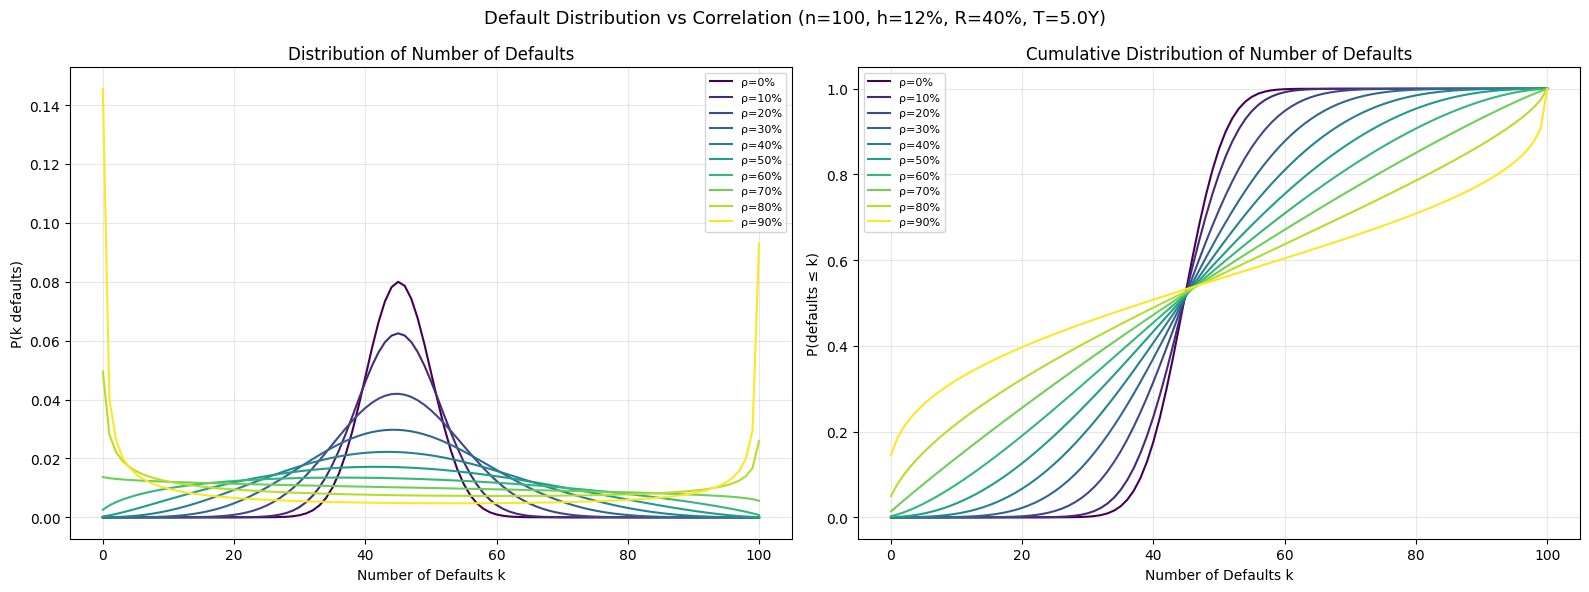

In [20]:
rho_grid = np.arange(0.0, 1.0, 0.1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(rho_grid)))

for i, rho_i in enumerate(rho_grid):
    if rho_i == 0:
        from scipy.stats import binom as binom_dist
        probs_i = np.array([binom_dist.pmf(k, n, PD) for k in k_grid])
    else:
        def prob_k_rho(k, rho_val):
            def integrand(x):
                px    = norm.cdf((d_minus - rho_val * x) / np.sqrt(1 - rho_val**2))
                binom = comb(n, k, exact=True)
                return binom * (px**k) * ((1 - px)**(n - k)) * norm.pdf(x)
            result, _ = quad(integrand, -10, 10, limit=200)
            return result
        probs_i = np.array([prob_k_rho(k, rho_i) for k in k_grid])

    cdf_i = np.cumsum(probs_i)
    label = f'ρ={rho_i:.0%}'

    axes[0].plot(k_grid, probs_i, color=colors[i], linewidth=1.5, label=label)
    axes[1].plot(k_grid, cdf_i,   color=colors[i], linewidth=1.5, label=label)

axes[0].set_title('Distribution of Number of Defaults')
axes[0].set_xlabel('Number of Defaults k')
axes[0].set_ylabel('P(k defaults)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Cumulative Distribution of Number of Defaults')
axes[1].set_xlabel('Number of Defaults k')
axes[1].set_ylabel('P(defaults ≤ k)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Default Distribution vs Correlation (n={n}, h={h:.0%}, R={R:.0%}, T={T}Y)', fontsize=13)
plt.tight_layout()
plt.show()

As correlation ρ increases, the default distribution becomes progressively flatter and more bimodal, with probability mass shifting away from the center and toward the tails. At ρ=0 (independence), the distribution is a tight binomial centered around the expected number of defaults (~45), with very little tail risk. As ρ rises, the systematic factor dominates: either the shared factor is favorable and few issuers default, or it is unfavorable and many default together. By ρ=90%, the distribution is nearly bimodal with significant mass near both 0 and 100 defaults. The expected loss is unchanged across all correlations since ρ does not affect the marginal PD, but the variance and tail risk increase dramatically. This is the key insight of correlated default modeling: correlation does not affect expected losses but has a profound effect on the distribution of losses, which is what matters for risk management, tranche pricing, and capital allocation.

## d. Compute the Mean and Standard Deviation of Pool Losses, for all correlation coefficients $\rho$ in the grid

Calculate, display and plot the Mean and Standard Deviation of pool losses for each $\rho$ in the grid.

Comment on the results.

── Mean and Std of Pool Losses by Correlation ─
     rho     Mean Loss       Std Dev
  ------------------------------------
      0%  $   27.0713  $    2.9857
     10%  $   27.0713  $    3.8082
     20%  $   27.0713  $    5.5926
     30%  $   27.0713  $    7.7008
     40%  $   27.0713  $    9.9398
     50%  $   27.0713  $   12.2609
     60%  $   27.0713  $   14.6678
     70%  $   27.0713  $   17.2008
     80%  $   27.0713  $   19.9586
     90%  $   27.0713  $   23.2105


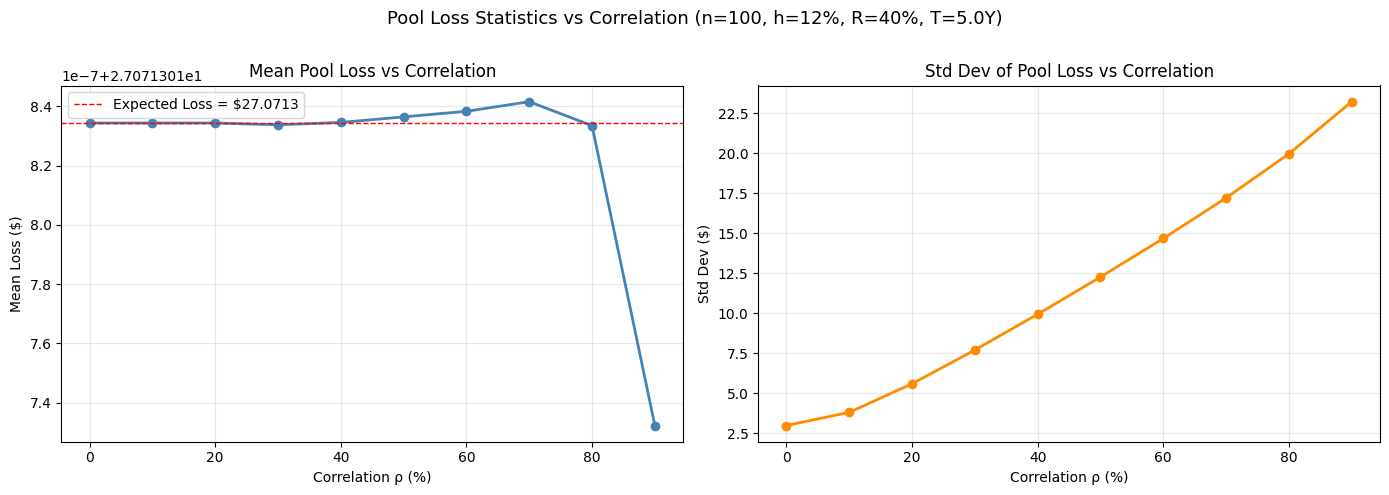

In [21]:
rho_grid_full = np.arange(0.0, 1.0, 0.1)

means = []
stds  = []

for rho_i in rho_grid_full:
    if rho_i == 0:
        probs_i = np.array([binom_dist.pmf(k, n, PD) for k in k_grid])
    else:
        probs_i = np.array([prob_k_rho(k, rho_i) for k in k_grid])

    loss_grid = k_grid * LGD * (notional / n)
    mean_i    = (loss_grid * probs_i).sum()
    var_i     = (loss_grid**2 * probs_i).sum() - mean_i**2
    std_i     = np.sqrt(var_i)

    means.append(mean_i)
    stds.append(std_i)

means = np.array(means)
stds  = np.array(stds)

print(f"── Mean and Std of Pool Losses by Correlation ─")
print(f"  {'rho':>6}  {'Mean Loss':>12}  {'Std Dev':>12}")
print(f"  {'-'*36}")
for rho_i, m, s in zip(rho_grid_full, means, stds):
    print(f"  {rho_i:>6.0%}  ${m:>10.4f}  ${s:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rho_grid_full * 100, means, color='steelblue', linewidth=2, marker='o')
axes[0].axhline(EL, color='red', linestyle='--', linewidth=1, label=f'Expected Loss = ${EL:.4f}')
axes[0].set_title('Mean Pool Loss vs Correlation')
axes[0].set_xlabel('Correlation ρ (%)')
axes[0].set_ylabel('Mean Loss ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rho_grid_full * 100, stds, color='darkorange', linewidth=2, marker='o')
axes[1].set_title('Std Dev of Pool Loss vs Correlation')
axes[1].set_xlabel('Correlation ρ (%)')
axes[1].set_ylabel('Std Dev ($)')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Pool Loss Statistics vs Correlation (n={n}, h={h:.0%}, R={R:.0%}, T={T}Y)', fontsize=13)
plt.tight_layout()
plt.show()

The mean pool loss is constant across all values of ρ at approximately $27.07, confirming that correlation has no effect on expected losses. This is because the marginal default probability of each issuer is determined solely by the hazard rate and time horizon, not by the dependence structure between issuers.
The standard deviation, however, increases monotonically and substantially with correlation, rising from a relatively low value at ρ=0 (where the law of large numbers diversifies away idiosyncratic risk) to a much higher value as ρ approaches 1 (where the pool behaves almost like a single large exposure). At ρ=0, the pool is well-diversified and losses are tightly concentrated around the mean. As ρ increases, the systematic factor increasingly drives all issuers together, making extreme outcomes (very few or very many defaults) far more likely and inflating the standard deviation dramatically. This is the fundamental trade-off in credit portfolio management: diversification reduces idiosyncratic risk but cannot hedge systematic risk, and higher correlation means a larger fraction of total risk is systematic and therefore undiversifiable.

------------------------------------------------------------------
# Problem 4: Derivation of fixed rate bond PVs and DV01s in `sympy`

Starting from the fair value formula for risky fixed rate bonds in the `flat yield model`, you will derive the formulas for
* Zero coupon bonds (principal payment only, no coupons) and
* "Interest Only" / IO bonds (coupon payments only, no principal payment)

Assume T+0 settlement and zero accrued.

### Flat Yield Model Parameters
* bond face value of 100%
* bond maturity T (in years),
* semi-annual coupon c,
* flat yield y

According to formula [5] in Lecture 1, the bond present value is given by:

\begin{align}
BondPV=B(0,T,c,y)
\end{align}

\begin{align}
=\sum_{k=1}^{2T}\frac{c}{2}\cdot e^{-k\cdot\frac{y}{2}}+e^{-T\cdot y}
\end{align}

\begin{align}
= 1+\frac{\frac{c}{2}-\left( e^{\frac{y}{2}}-1 \right)}{e^{\frac{y}{2}}-1 } \cdot \left(1-e^{-T\cdot y}\right)
\end{align}


The example code below explains how to implement the present value function for the generic fixed rate bond.

It uses the 'sympy' library (symbolic mathematics) to translate mathematical formulas into a sympy symbolic equation, as described in the solution to Homework 3, Problem 2.

The sympy symbolic equation is converted into a Python function via sympy.lambdify.

The function `plot_bond_function_surface(bond_func, 'Plot Title')` plots the Python bond function on a "yield x maturity" 2D discretization grid:

* in yield space: [y from 0% to 10% in steps of 0.5%] and
* in time-to-maturity space: [T from 1Y to 20Y in steps of 1Y].

We assume a bond coupon c of 5% for plotting purposes.

Analytic formula for bond_pv: (1 - exp(-T*y))*(c/2 - exp(y/2) + 1)/(exp(y/2) - 1) + 1


(1 - exp(-T*y))*(c/2 - exp(y/2) + 1)/(exp(y/2) - 1) + 1

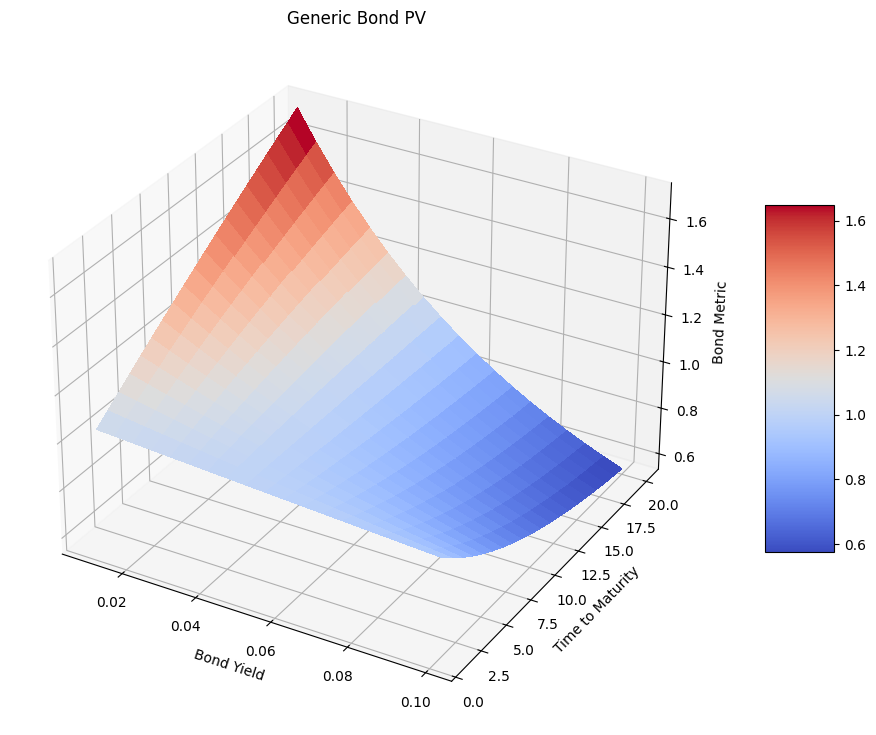

In [22]:
# define symbolic variables
t = sp.symbols('T')
c = sp.symbols('c')
y = sp.symbols('y')

# define symbolic equation for bond pv
bond_pv_eq =  1 + (c/2 -(sp.exp(y/2) - 1)) / (sp.exp(y/2) - 1) * (1 - sp.exp(-t*y))
print('Analytic formula for bond_pv:', bond_pv_eq)
display(bond_pv_eq)

# create function(y,T,y) from equation
bond_pv_func = sp.lambdify([c,t,y], bond_pv_eq)

# Plot the surface
plot_bond_function_surface(bond_pv_func, 'Generic Bond PV')


## a. Derive and plot the DV01 of a Fixed rate bond

Use the sympy "diff()" function to compute & display the derivative of the fixed rate bond PV with respect to the bond yield.

Plot the bond DV01 surface on the "yield x maturity" 2D discretization grid.


Bond PV:


(1 - exp(-T*y))*(c/2 - exp(y/2) + 1)/(exp(y/2) - 1) + 1

DV01 = dBondPV/dy:


(T*c*exp(y/2)/2 - T*c/2 + 2*T*exp(y/2) - T*exp(y) - T + c*exp(y/2)/4 - c*exp(y*(T + 1/2))/4)*exp(-T*y)/(-2*exp(y/2) + exp(y) + 1)

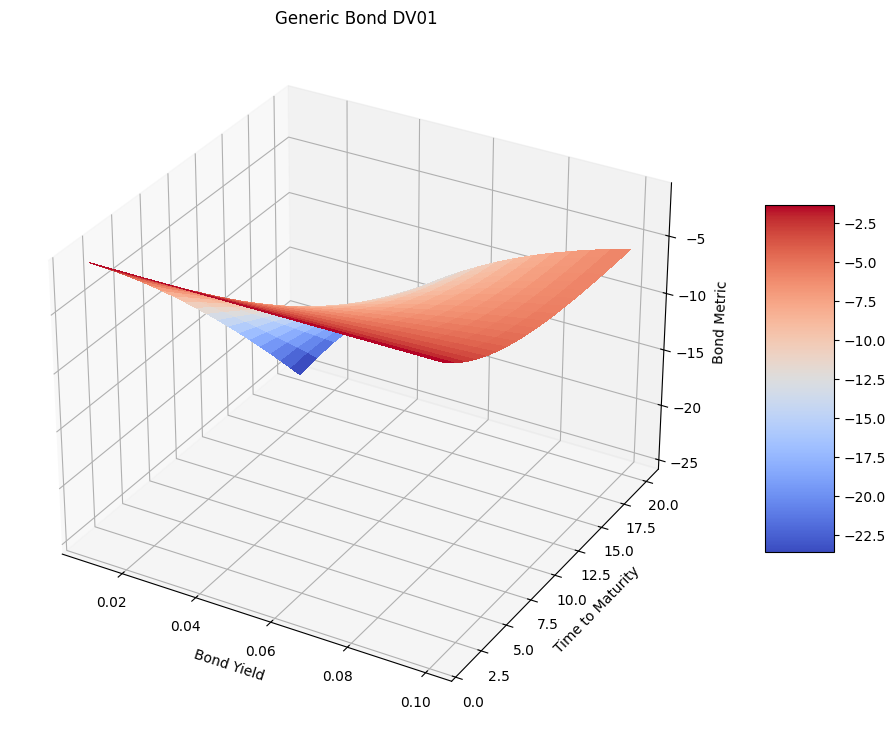

In [23]:
import sympy as sp

t, c, y = sp.symbols('T c y')

bond_pv_eq = 1 + (c/2 - (sp.exp(y/2) - 1)) / (sp.exp(y/2) - 1) * (1 - sp.exp(-t*y))

dv01_eq = sp.diff(bond_pv_eq, y)
dv01_eq_simplified = sp.simplify(dv01_eq)

print('Bond PV:')
display(bond_pv_eq)
print('DV01 = dBondPV/dy:')
display(dv01_eq_simplified)

bond_pv_func = sp.lambdify([c, t, y], bond_pv_eq)
dv01_func    = sp.lambdify([c, t, y], dv01_eq)

plot_bond_function_surface(dv01_func, 'Generic Bond DV01')

## b. Derive and plot the present value functions for a Zero Coupon bond.

Derive and display the analytic formula for a Zero Coupon bond PV.

Plot the Zero Coupon bond PV surface on the "yield x maturity" 2D discretization grid.

Zero Coupon Bond PV:


exp(-T*y)

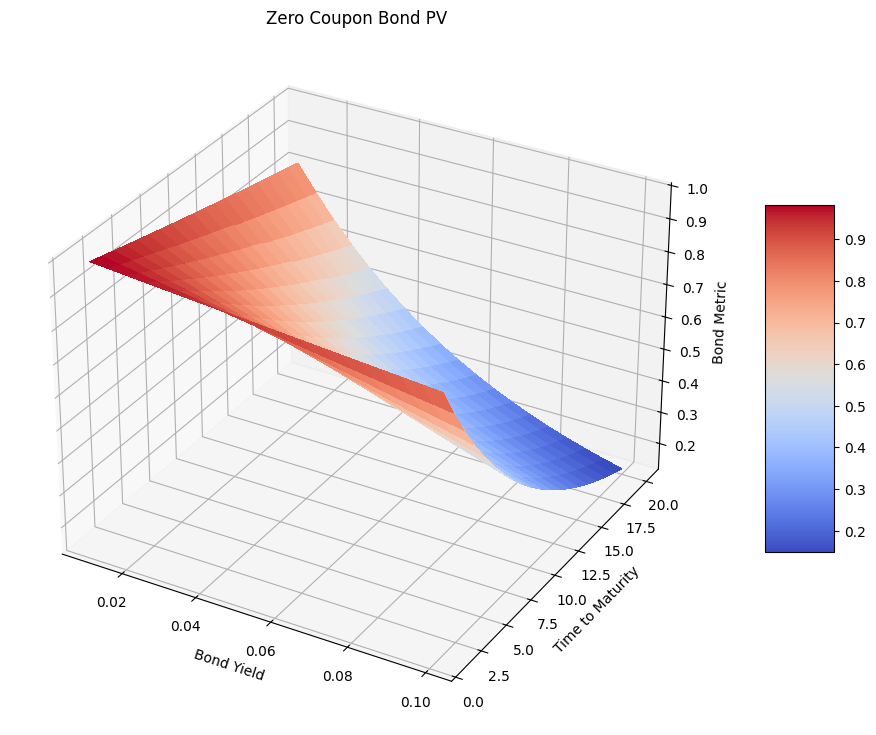

In [24]:
zc_pv_eq = bond_pv_eq.subs(c, 0)
zc_pv_eq_simplified = sp.simplify(zc_pv_eq)

print('Zero Coupon Bond PV:')
display(zc_pv_eq_simplified)

zc_pv_func = sp.lambdify([t, y], zc_pv_eq_simplified)

plot_bond_function_surface(lambda c, t, y: zc_pv_func(t, y), 'Zero Coupon Bond PV')

## c. Derive and plot the DV01 of a Zero Coupon bond.

Use the sympy "diff()" function to compute & display the derivative of the Zero Coupon bond PV with respect to the bond yield.

Plot the Zero Coupon bond DV01 surface on the "yield x maturity" 2D discretization grid.


Zero Coupon Bond DV01 = dZC_PV/dy:


-T*exp(-T*y)

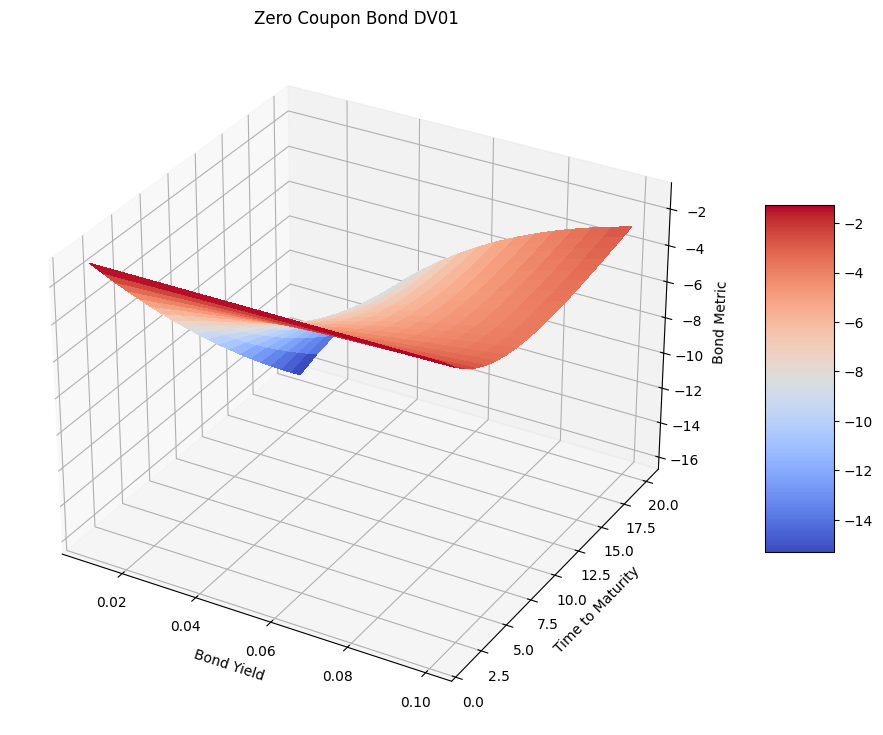

In [25]:
zc_dv01_eq = sp.diff(zc_pv_eq_simplified, y)
zc_dv01_eq_simplified = sp.simplify(zc_dv01_eq)

print('Zero Coupon Bond DV01 = dZC_PV/dy:')
display(zc_dv01_eq_simplified)

zc_dv01_func = sp.lambdify([t, y], zc_dv01_eq_simplified)

plot_bond_function_surface(lambda c, t, y: zc_dv01_func(t, y), 'Zero Coupon Bond DV01')

## d. Derive and plot the present value function for an Interest Only bond.

Derive and display the analytic formula for an Interest Only bond PV.

Plot the Interest Only bond PV surface on the "yield x maturity" 2D discretization grid.

Keep in mind that any generic fixed rate bond can be decomposed into Zero Coupon and Interest Only components.

Interest Only Bond PV = Bond PV - Zero Coupon PV:


c*(1 - exp(T*y))*exp(-T*y)/(2*(1 - exp(y/2)))

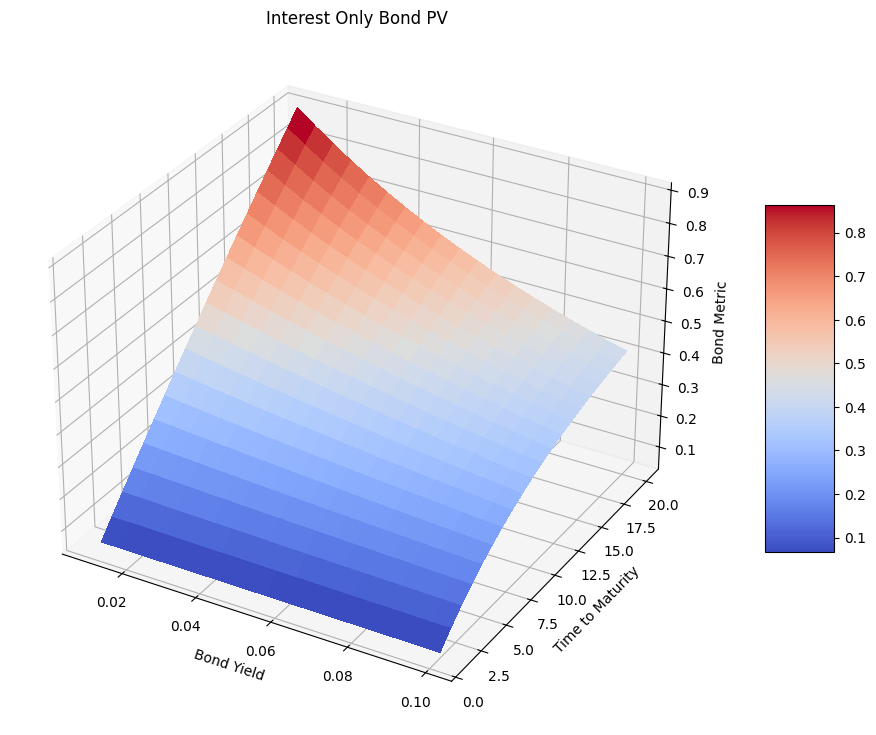

In [26]:
io_pv_eq = bond_pv_eq - zc_pv_eq_simplified
io_pv_eq_simplified = sp.simplify(io_pv_eq)

print('Interest Only Bond PV = Bond PV - Zero Coupon PV:')
display(io_pv_eq_simplified)

io_pv_func = sp.lambdify([c, t, y], io_pv_eq_simplified)

plot_bond_function_surface(io_pv_func, 'Interest Only Bond PV')

## e. Derive and plot the DV01 of an Interest Only bond.

Use the sympy "diff()" function to compute and display the derivative of the Interest Only bond PV.

Plot the Interest Only bond DV01 surface on the "yield x maturity" 2D discretization grid.


Interest Only Bond DV01 = dIO_PV/dy:


c*(2*T*exp(y/2) - 2*T + exp(y/2) - exp(T*y + y/2))*exp(-T*y)/(4*(-2*exp(y/2) + exp(y) + 1))


Sanity check: Bond DV01 = ZC DV01 + IO DV01


0

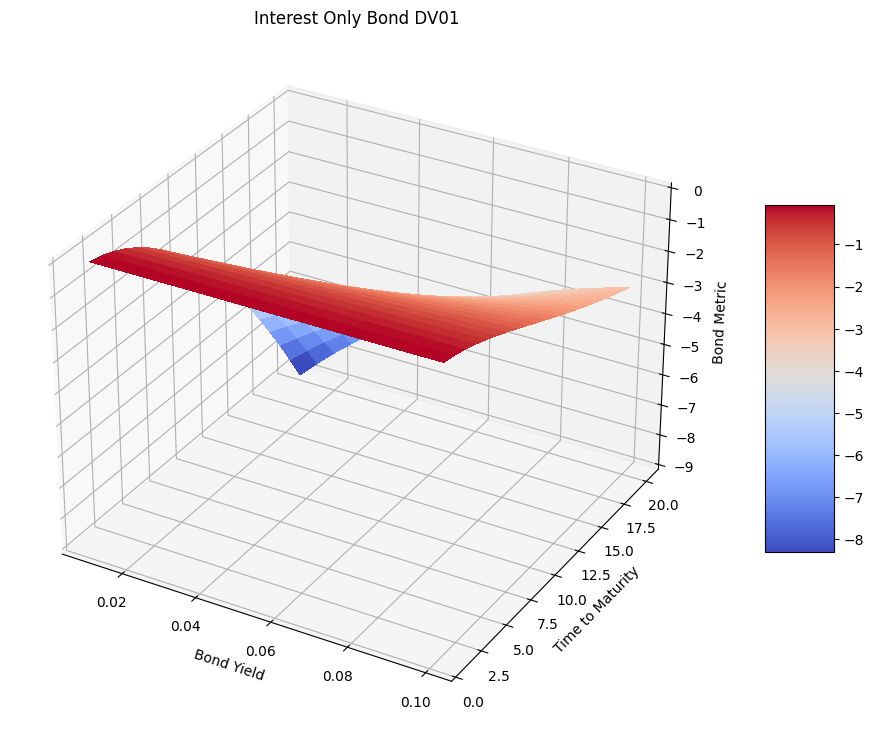

In [27]:
io_dv01_eq = sp.diff(io_pv_eq_simplified, y)
io_dv01_eq_simplified = sp.simplify(io_dv01_eq)

print('Interest Only Bond DV01 = dIO_PV/dy:')
display(io_dv01_eq_simplified)

io_dv01_func = sp.lambdify([c, t, y], io_dv01_eq_simplified)

plot_bond_function_surface(io_dv01_func, 'Interest Only Bond DV01')

print('\nSanity check: Bond DV01 = ZC DV01 + IO DV01')
display(sp.simplify(dv01_eq - zc_dv01_eq_simplified - io_dv01_eq_simplified))